In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy import stats
import math

In [2]:
random_state = 42
np.random.seed(random_state)

In [3]:
df = pd.read_csv('flight_price.csv')

In [4]:

print(f"Data Size: {df.shape}")
df.head()

Data Size: (300153, 12)


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [6]:
df.sample(3)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
27131,27131,Air_India,AI-506,Delhi,Morning,one,Early_Morning,Kolkata,Economy,19.75,40,7366
266857,266857,Vistara,UK-706,Kolkata,Morning,one,Night,Mumbai,Business,9.83,42,64831
141228,141228,Vistara,UK-772,Kolkata,Morning,one,Night,Bangalore,Economy,10.50,41,6195


In [7]:
# memisahkan kategori
numeric = ['duration', 'days_left', 'price']
categorical = ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']

In [8]:
for col in categorical:
    print(f"Kolom: {col}")
    print(f"jumlah kategori unik: {df[col].nunique()}")
    print(f"kategori unik: {df[col].unique()}")

Kolom: airline
jumlah kategori unik: 6
kategori unik: ['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']
Kolom: flight
jumlah kategori unik: 1561
kategori unik: ['SG-8709' 'SG-8157' 'I5-764' ... '6E-7127' '6E-7259' 'AI-433']
Kolom: source_city
jumlah kategori unik: 6
kategori unik: ['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
Kolom: departure_time
jumlah kategori unik: 6
kategori unik: ['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']
Kolom: stops
jumlah kategori unik: 3
kategori unik: ['zero' 'one' 'two_or_more']
Kolom: arrival_time
jumlah kategori unik: 6
kategori unik: ['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night']
Kolom: destination_city
jumlah kategori unik: 6
kategori unik: ['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
Kolom: class
jumlah kategori unik: 2
kategori unik: ['Economy' 'Business']


In [9]:
df.drop(columns=['Unnamed: 0', 'flight'], inplace=True)

In [10]:
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
df['days_left'] = pd.to_numeric(df['days_left'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

df['duration'] = df['duration'].astype(float)
df['days_left'] = df['days_left'].astype(float)
df['price'] = df['price'].astype(float)

In [11]:
df.isnull().sum()

,0
airline,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0
price,0


In [12]:
df.duplicated().sum()

np.int64(2213)

In [13]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [14]:
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=random_state,
)

print(f"Ukuran Data Train : {df_train.shape}")
print(f"Ukuran Data Test  : {df_test.shape}\n")

Ukuran Data Train : (240122, 10)
Ukuran Data Test  : (60031, 10)



In [15]:
#encoding
ohe_columns = ['airline', 'source_city', 'departure_time', 'arrival_time', 'destination_city']
df_train = pd.get_dummies(df_train, columns=ohe_columns, drop_first=True, dtype=int)
df_test = pd.get_dummies(df_test, columns=ohe_columns,drop_first=True, dtype=int)

df_train, df_test = df_train.align(
    df_test,
    join='left',
    axis=1,
    fill_value=0
)

stops_mapping = {
    'zero': 0,
    'one': 1,
    'two_or_more': 2
    }

class_mapping = {
    'Economy': 0,
    'Business': 1
    }

df_train['stops_encoded'] = df_train['stops'].map(stops_mapping)
df_test['stops_encoded'] = df_test['stops'].map(stops_mapping)

df_train['class_encoded'] = df_train['class'].map(class_mapping)
df_test['class_encoded'] = df_test['class'].map(class_mapping)

df_train = df_train.drop(columns=['class', 'stops'])
df_test = df_test.drop(columns=['class', 'stops'])

In [16]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 240122 entries, 148417 to 121958
Data columns (total 30 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   duration                      240122 non-null  float64
 1   days_left                     240122 non-null  float64
 2   price                         240122 non-null  float64
 3   airline_Air_India             240122 non-null  int64  
 4   airline_GO_FIRST              240122 non-null  int64  
 5   airline_Indigo                240122 non-null  int64  
 6   airline_SpiceJet              240122 non-null  int64  
 7   airline_Vistara               240122 non-null  int64  
 8   source_city_Chennai           240122 non-null  int64  
 9   source_city_Delhi             240122 non-null  int64  
 10  source_city_Hyderabad         240122 non-null  int64  
 11  source_city_Kolkata           240122 non-null  int64  
 12  source_city_Mumbai            240122 non-nul

In [18]:
print(df_train.shape)
print(df_test.shape)

set(df_train.columns) - set(df_test.columns)
set(df_test.columns) - set(df_train.columns)

(240122, 30)
(60031, 30)


set()

In [19]:
x = df.drop(columns=['price'])
y = df['price']

In [20]:
x_train = df_train.drop(columns=['price'])
y_train = df_train['price']

x_test = df_test.drop(columns=['price'])
y_test = df_test['price']

In [21]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 240122 entries, 148417 to 121958
Data columns (total 29 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   duration                      240122 non-null  float64
 1   days_left                     240122 non-null  float64
 2   airline_Air_India             240122 non-null  int64  
 3   airline_GO_FIRST              240122 non-null  int64  
 4   airline_Indigo                240122 non-null  int64  
 5   airline_SpiceJet              240122 non-null  int64  
 6   airline_Vistara               240122 non-null  int64  
 7   source_city_Chennai           240122 non-null  int64  
 8   source_city_Delhi             240122 non-null  int64  
 9   source_city_Hyderabad         240122 non-null  int64  
 10  source_city_Kolkata           240122 non-null  int64  
 11  source_city_Mumbai            240122 non-null  int64  
 12  departure_time_Early_Morning  240122 non-nul

In [35]:
df.groupby('class')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
Business,93487.0,52540.081124,12969.314606,12000.0,45185.0,53164.0,60396.0,123071.0
Economy,206666.0,6572.342383,3743.519517,1105.0,4173.0,5772.0,7746.0,42349.0


In [37]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [38]:
y_pred = rf.predict(x_test)

In [39]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.9847771142820567
MAE: 1086.7295236816137
RMSE: 2801.2725215809537


In [40]:
importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': rf.feature_importances_
})

importance.sort_values('Importance', ascending=False)

,Feature,Importance
28,class_encoded,0.879856
0,duration,0.058757
1,days_left,0.018540
6,airline_Vistara,0.005691
2,airline_Air_India,0.004618
8,source_city_Delhi,0.003908
23,destination_city_Delhi,0.003638
11,source_city_Mumbai,0.002442
26,destination_city_Mumbai,0.002077
24,destination_city_Hyderabad,0.001920


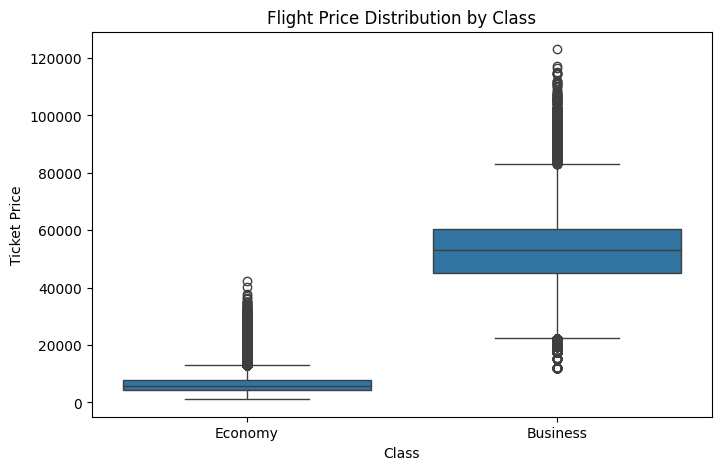

In [44]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='class', y='price')

plt.title('Flight Price Distribution by Class')
plt.xlabel('Class')
plt.ylabel('Ticket Price')

plt.show()

# Conclusion

The Random Forest Regressor achieved strong predictive performance in estimating flight ticket prices, with an R² score of **0.9848**, an MAE of **1086.73**, and an RMSE of **2801.27**. These results indicate that the model can accurately capture the relationship between flight attributes and ticket prices while maintaining good generalization on unseen data.

Feature importance analysis showed that **flight class** was the most influential factor affecting ticket prices, contributing approximately **87.99%** of the model's decisions. Other important features included **flight duration** and **days left before departure**, suggesting that ticket class and flight characteristics play significant roles in determining airfare.
